Loading All Essential Libraries

In [55]:
import pandas as pd
import numpy as np

import seaborn as sns
sns.set(rc = {'figure.figsize':(10,4)})

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import statsmodels as sm

By using this line of code, all data will only show 2 decimals.

In [3]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
data = pd.read_csv('../data/raw/healthcare_fraud_detection.csv')

data.head(5)


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.00
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.00
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.00
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.00
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.00


Checking Data Types

In [5]:
data.dtypes

Provider_ID                               object
Claim_ID                                  object
Patient_Age                                int64
Patient_Gender                            object
Diagnosis_Code                            object
Procedure_Code                             int64
Claim_Amount                             float64
Approved_Amount                          float64
Insurance_Type                            object
Claim_Submission_Date                     object
Days_Between_Service_and_Claim             int64
Number_of_Claims_Per_Provider_Monthly      int64
Provider_Specialty                        object
Patient_State                             object
Claim_Status                              object
Is_Fraud                                   int64
Length_of_Stay                             int64
Visit_Type                                object
Chronic_Condition_Flag                     int64
Prior_Visits_12m                         float64
dtype: object

In [6]:
data.tail(5)

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
9995,P0289,C0009995,79,Male,E78.5,71046,590.19,205.00,Private,2024-09-24,2,115,Internal Medicine,PA,Approved,1,2,Inpatient,1,3.00
9996,P0248,C0009996,66,Male,K21.9,93000,219.73,191.89,Self-Pay,2023-01-04,6,73,Orthopedics,IL,Approved,0,5,Inpatient,0,6.00
9997,P0122,C0009997,43,Female,F41.9,99213,505.24,447.94,Medicare,2024-06-30,6,59,Neurology,OH,Rejected,0,5,Emergency,1,0.00
9998,P0072,C0009998,39,Female,I10,93000,564.25,507.18,Medicare,2022-03-15,8,55,Cardiology,TX,Pending,0,5,Emergency,0,6.00
9999,P0137,C0009999,26,Male,J18.9,71046,564.52,563.74,Medicaid,2023-01-24,2,86,Neurology,CA,Approved,0,3,Outpatient,0,NaN


Checking Column Names

In [7]:
data.columns

Index(['Provider_ID', 'Claim_ID', 'Patient_Age', 'Patient_Gender',
       'Diagnosis_Code', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount',
       'Insurance_Type', 'Claim_Submission_Date',
       'Days_Between_Service_and_Claim',
       'Number_of_Claims_Per_Provider_Monthly', 'Provider_Specialty',
       'Patient_State', 'Claim_Status', 'Is_Fraud', 'Length_of_Stay',
       'Visit_Type', 'Chronic_Condition_Flag', 'Prior_Visits_12m'],
      dtype='object')

Checking Descriptive Summary of Data

In [8]:
data.describe()

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,9650.00
mean,49.76,86905.21,572.80,475.51,14.41,68.63,0.08,2.20,0.29,3.03
std,17.91,14965.32,406.20,323.26,8.49,14.91,0.28,1.71,0.45,1.72
min,1.00,36415.00,60.21,50.35,0.00,42.00,0.00,0.00,0.00,0.00
25%,37.75,80053.00,305.20,257.20,7.00,60.00,0.00,1.00,0.00,2.00
50%,50.00,93000.00,461.23,388.37,14.00,66.00,0.00,2.00,0.00,3.00
75%,62.00,99213.00,711.37,598.35,22.00,72.00,0.00,3.00,1.00,4.00
max,95.00,99214.00,6590.70,4270.89,29.00,144.00,1.00,5.00,1.00,12.00


Checking Duplicates

In [9]:
data.duplicated().sum()

np.int64(0)

Checking Cardinality of Data

In [10]:
data.nunique()

Provider_ID                                300
Claim_ID                                 10000
Patient_Age                                 95
Patient_Gender                               2
Diagnosis_Code                              10
Procedure_Code                               9
Claim_Amount                              9460
Approved_Amount                           9373
Insurance_Type                               4
Claim_Submission_Date                     1476
Days_Between_Service_and_Claim              30
Number_of_Claims_Per_Provider_Monthly      100
Provider_Specialty                           6
Patient_State                                8
Claim_Status                                 3
Is_Fraud                                     2
Length_of_Stay                               5
Visit_Type                                   3
Chronic_Condition_Flag                       2
Prior_Visits_12m                            13
dtype: int64

Checking Null Values

In [11]:
data.isna().sum()

Provider_ID                                0
Claim_ID                                   0
Patient_Age                                0
Patient_Gender                             0
Diagnosis_Code                             0
Procedure_Code                             0
Claim_Amount                               0
Approved_Amount                            0
Insurance_Type                           350
Claim_Submission_Date                      0
Days_Between_Service_and_Claim             0
Number_of_Claims_Per_Provider_Monthly      0
Provider_Specialty                       350
Patient_State                              0
Claim_Status                               0
Is_Fraud                                   0
Length_of_Stay                             0
Visit_Type                                 0
Chronic_Condition_Flag                     0
Prior_Visits_12m                         350
dtype: int64

Checking Null Values as Percentage

In [12]:
(data.isna().sum() / len(data)) * 100

Provider_ID                             0.00
Claim_ID                                0.00
Patient_Age                             0.00
Patient_Gender                          0.00
Diagnosis_Code                          0.00
Procedure_Code                          0.00
Claim_Amount                            0.00
Approved_Amount                         0.00
Insurance_Type                          3.50
Claim_Submission_Date                   0.00
Days_Between_Service_and_Claim          0.00
Number_of_Claims_Per_Provider_Monthly   0.00
Provider_Specialty                      3.50
Patient_State                           0.00
Claim_Status                            0.00
Is_Fraud                                0.00
Length_of_Stay                          0.00
Visit_Type                              0.00
Chronic_Condition_Flag                  0.00
Prior_Visits_12m                        3.50
dtype: float64

Checking Duplicate Values in data

In [13]:
data.duplicated().sum()

np.int64(0)

Checking If my target variable is balanced

In [14]:
data['Is_Fraud'].value_counts()



Is_Fraud
0    9171
1     829
Name: count, dtype: int64

Filling Null Values in Prior Visit Column - Mandatory Before Converting Data Types

In [15]:
data['Prior_Visits_12m'] = data['Prior_Visits_12m'].fillna(0)



In [16]:
data.isnull().sum()

Provider_ID                                0
Claim_ID                                   0
Patient_Age                                0
Patient_Gender                             0
Diagnosis_Code                             0
Procedure_Code                             0
Claim_Amount                               0
Approved_Amount                            0
Insurance_Type                           350
Claim_Submission_Date                      0
Days_Between_Service_and_Claim             0
Number_of_Claims_Per_Provider_Monthly      0
Provider_Specialty                       350
Patient_State                              0
Claim_Status                               0
Is_Fraud                                   0
Length_of_Stay                             0
Visit_Type                                 0
Chronic_Condition_Flag                     0
Prior_Visits_12m                           0
dtype: int64

Missing Data Mechanism Analysis - Filling Null Values Based on Correlation

In [17]:
#data['Provider_Specialty'].value_counts()

data.groupby('Provider_Specialty')['Diagnosis_Code'].count().reset_index()


,Provider_Specialty,Diagnosis_Code
0,Cardiology,1366
1,General Practice,1878
2,Internal Medicine,2019
3,Neurology,1516
4,Orthopedics,1616
5,Pulmonology,1255


In [18]:
missed_Provider_Specialty= data[data['Provider_Specialty'].isnull()][['Provider_Specialty', 'Diagnosis_Code']]
print(missed_Provider_Specialty)

     Provider_Specialty Diagnosis_Code
7                   NaN            I10
14                  NaN          F41.9
20                  NaN          F41.9
23                  NaN          E78.5
29                  NaN          F41.9
...                 ...            ...
9786                NaN          F41.9
9879                NaN          E11.9
9931                NaN          J18.9
9972                NaN          E78.5
9978                NaN          J18.9

[350 rows x 2 columns]


Data Types Conversion for deeper ongoing analysis

In [19]:
data['Claim_Submission_Date'] = pd.to_datetime(data['Claim_Submission_Date'])

data['Procedure_Code'] = data['Procedure_Code'].astype('category')

data['Patient_Gender'] = data['Patient_Gender'].astype('category')

data['Patient_State'] = data['Patient_State'].astype('category')

data['Claim_Status'] = data['Claim_Status'].astype('category')

data['Visit_Type'] = data['Visit_Type'].astype('category')

data['Prior_Visits_12m'] = data['Prior_Visits_12m'].astype('int')

data['Insurance_Type'] = data['Insurance_Type'].astype('category')

data['Provider_Specialty'] = data['Provider_Specialty'].astype('category')

data['Diagnosis_Code'] = data['Diagnosis_Code'].astype('category')

data['Is_Fraud'] = data['Is_Fraud'].astype('bool')

data['Chronic_Condition_Flag'] = data['Chronic_Condition_Flag'].astype('bool')



In [20]:
data.dtypes

Provider_ID                                      object
Claim_ID                                         object
Patient_Age                                       int64
Patient_Gender                                 category
Diagnosis_Code                                 category
Procedure_Code                                 category
Claim_Amount                                    float64
Approved_Amount                                 float64
Insurance_Type                                 category
Claim_Submission_Date                    datetime64[ns]
Days_Between_Service_and_Claim                    int64
Number_of_Claims_Per_Provider_Monthly             int64
Provider_Specialty                             category
Patient_State                                  category
Claim_Status                                   category
Is_Fraud                                           bool
Length_of_Stay                                    int64
Visit_Type                                     c

Checking If There's Any Impossible Values in Dataset

In [21]:
data.describe().T[['min', 'max']]

,min,max
Patient_Age,1.00,95.00
Claim_Amount,60.21,6590.70
Approved_Amount,50.35,4270.89
Claim_Submission_Date,2021-01-06 00:00:00,2025-01-26 00:00:00
Days_Between_Service_and_Claim,0.00,29.00
Number_of_Claims_Per_Provider_Monthly,42.00,144.00
Length_of_Stay,0.00,5.00
Prior_Visits_12m,0.00,12.00


In [22]:
data[(data['Patient_Age'] < 0) | (data['Claim_Amount'] < 0) | (data['Approved_Amount'] < 0)]

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m


In [23]:
data[data['Approved_Amount'] > data['Claim_Amount']]

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m


In [24]:
data['Claim_Status'].unique().T

['Approved', 'Pending', 'Rejected']
Categories (3, object): ['Approved', 'Pending', 'Rejected']

Handling Missing Values 

We can't randomly fill missing values in Insurance Type and Provider Specialty column. We have to analyze data to check pattern and then fill values accordingly

In [25]:
data.head(3)

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,False,0,Outpatient,True,2
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,False,5,Inpatient,True,2
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,False,5,Inpatient,True,3


In [26]:
data.groupby('Insurance_Type')['Provider_ID'].value_counts()

Insurance_Type  Provider_ID
Medicaid        P0223          18
                P0113          15
                P0036          14
                P0058          14
                P0075          14
                               ..
Self-Pay        P0197           2
                P0210           2
                P0264           2
                P0280           2
                P0134           1
Name: count, Length: 1200, dtype: int64

As we have not find any measurable relationship between insurance type column and other columns so we will simply use the mode method

In [27]:
data['Insurance_Type'] = data['Insurance_Type'].fillna(data['Insurance_Type'].mode()[0])

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Provider_ID                            10000 non-null  object        
 1   Claim_ID                               10000 non-null  object        
 2   Patient_Age                            10000 non-null  int64         
 3   Patient_Gender                         10000 non-null  category      
 4   Diagnosis_Code                         10000 non-null  category      
 5   Procedure_Code                         10000 non-null  category      
 6   Claim_Amount                           10000 non-null  float64       
 7   Approved_Amount                        10000 non-null  float64       
 8   Insurance_Type                         10000 non-null  category      
 9   Claim_Submission_Date                  10000 non-null  datetim

Filling Provider Specialty by analyzing its relation with other variables.

In [29]:
data.groupby('Provider_Specialty')['Diagnosis_Code'].value_counts()


Provider_Specialty  Diagnosis_Code
Cardiology          K21.9             159
                    N39.0             151
                    J06.9             144
                    F41.9             136
                    J18.9             135
                    E11.9             134
                    I25.10            132
                    E78.5             131
                    I10               129
                    M54.5             115
General Practice    E11.9             210
                    I25.10            205
                    F41.9             202
                    M54.5             200
                    K21.9             196
                    N39.0             190
                    I10               180
                    E78.5             176
                    J18.9             162
                    J06.9             157
Internal Medicine   E78.5             214
                    M54.5             213
                    E11.9             212

In [30]:
data['Provider_Specialty'] = data.groupby('Diagnosis_Code')['Provider_Specialty'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
)

Handling Outliers in Claim Amount

In [43]:
minimum, Q1, median, Q3, maximum = np.quantile(data['Claim_Amount'],[0, 0.25, 0.50, 0.75, 1.0])


In [45]:
(minimum, Q1, median, Q3, maximum)

(np.float64(60.21),
 np.float64(305.205),
 np.float64(461.225),
 np.float64(711.365),
 np.float64(6590.7))

In [48]:
IQR = Q3 - Q1
print(IQR)

406.16


In [49]:
Lower_Fence = Q1 - 1.5*(IQR)
Higher_Fence = Q3 + 1.5*(IQR)

In [52]:
print(Lower_Fence)
print(Higher_Fence)

-304.035
1320.605


<Axes: ylabel='Claim_Amount'>

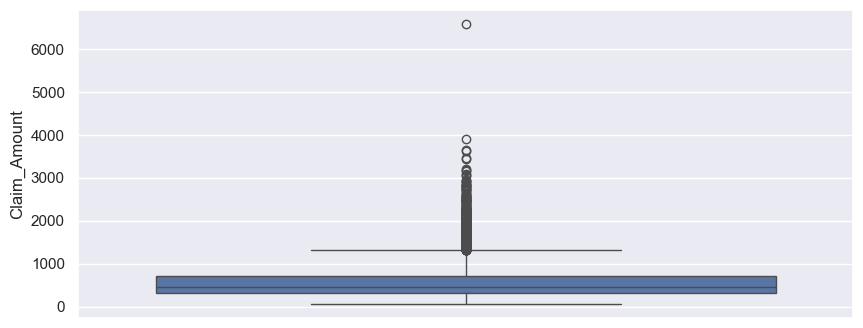

In [56]:
sns.boxplot(data['Claim_Amount'])

Fidning Outliers in All Numerical Columns

In [57]:
# Select all numeric columns automatically
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Loop through each numeric column and calculate outliers
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers found")

Patient_Age: 45 outliers found
Claim_Amount: 552 outliers found
Approved_Amount: 501 outliers found
Days_Between_Service_and_Claim: 0 outliers found
Number_of_Claims_Per_Provider_Monthly: 817 outliers found
Length_of_Stay: 0 outliers found
Prior_Visits_12m: 105 outliers found


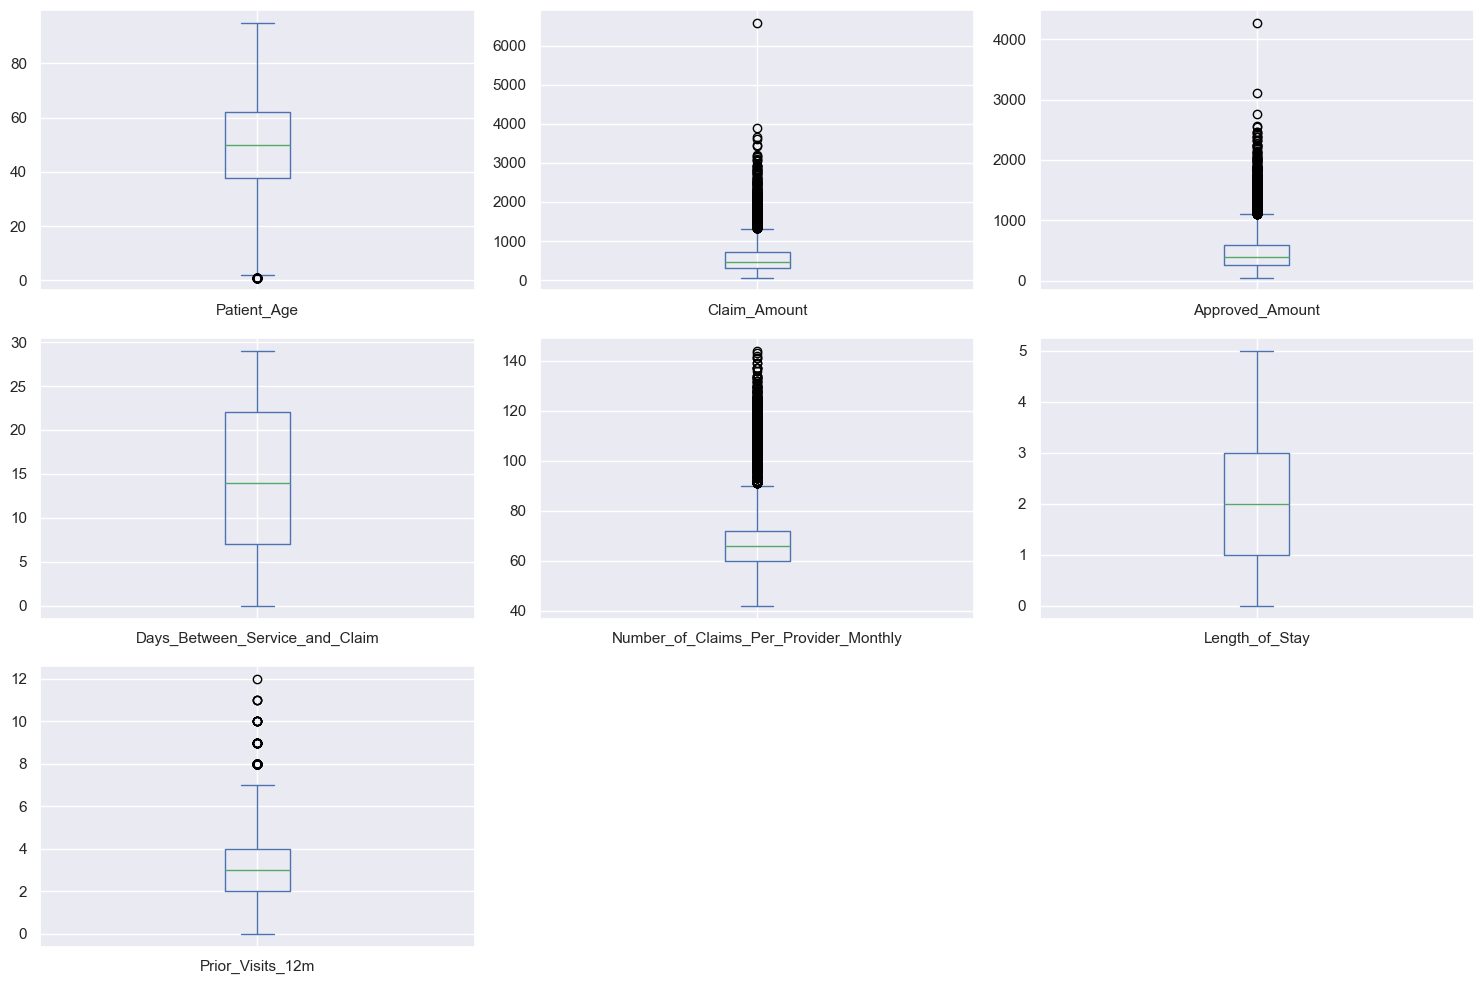

In [59]:

# Automatically plot boxplots for all numeric columns in one grid
data[numeric_cols].plot(kind='box', subplots=True, layout=(3, 3), figsize=(15, 10))
plt.tight_layout()
plt.show()

Saving new file

In [60]:

data.to_csv('cleaned_healthcare_claims.csv', index=False)